In [18]:
#source('/research_jude/rgs01_jude/groups/jxugrp/home/common/Lab_Members/WenhuoHu/script/utils.r')
base_dir = '/scratch/mjehangir/manuscript_figures/figures'
setwd(base_dir)

In [19]:
# Load required libraries
library(tidyverse)
library(corrplot)
library(ggpubr)
library(tidyverse)
library(readxl)
library(DESeq2)
library(dplyr)
library(ggplot2)
library(gridExtra)
library(ggrepel)
library(ComplexHeatmap)
library(tidyr)
library(dplyr)
library(GGally)

In [25]:
# ------------------------
# Load CNV & Telomere data
# ------------------------
cnv_telo <- read.delim("CNVs_TEL_merged_final_data.tsv", header = TRUE, sep = "\t")

# ------------------------
# Load Structural Variant (SV) data
# ------------------------
sv_data <- read.delim("SNVs_greater_than_1bp.txt", header = TRUE, sep = "\t") %>%
  group_by(filename, chr, type) %>%
  summarise(SV_count = n(), .groups = 'drop') %>%
  spread(key = type, value = SV_count, fill = 0)
# ------------------------
# Load Aneuploidy data
# ------------------------
aneuploidy <- read.delim("output_taylor_aneuploidy.txt", header = TRUE, sep = "\t") 
head(cnv_telo)
head(sv_data)
head(aneuploidy)

,SampleID,chr,assigned_arm,Length,total_length_neutral,total_length_gain,total_length_loss,proportion_neutral,proportion_gain,proportion_loss,final_average_TL_p75,chr_order,arm
,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>
1,2436A,chr1,chr1p,124048267,27820989,0,0,0.22427552,0.000000000,0.0000000,5221.000,1,p
2,2436A,chr1,chr1q,124339061,0,200151,0,0.00000000,0.001609719,0.0000000,5051.167,1,q
3,2436A,chr10,chr10q,94108943,26230785,0,18621836,0.27872787,0.000000000,0.1978753,2732.750,10,q
4,2436A,chr11,chr11p,52743313,3002850,0,0,0.05693328,0.000000000,0.0000000,6766.000,11,p
5,2436A,chr12,chr12p,35911664,4003740,0,0,0.11148857,0.000000000,0.0000000,5319.400,12,p
6,2436A,chr12,chr12q,97412884,9809163,0,0,0.10069677,0.000000000,0.0000000,6085.000,12,q


filename,chr,DEL,DUP,INS,INV
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
2436A,chr1,1132,1,0,2
2436A,chr10,789,1,0,0
2436A,chr11,683,1,0,0
2436A,chr12,717,0,0,4
2436A,chr13,679,0,0,0
2436A,chr14,670,0,0,0


,SampleID,aneuploidy_score,aneuploidy_amp_score,aneuploidy_del_score,max_loss_arm_n,max_loss_arm_wmean,max_loss_arm_wsd,max_gain_arm_n,max_gain_arm_wmean,max_gain_arm_wsd
,<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<dbl>,<dbl>
1,2436A,0,0,0,3,1.4183823,141.32710,2,2.2372041,668.25431
2,3188,0,0,0,2,0.3704812,83.29380,2,0.6899067,21.68964
3,3988,1,1,0,5,1.5846938,315.51340,5,1.5846938,315.51340
4,6265D,2,0,2,2,0.5528858,115.79878,4,0.5982750,59.56143
5,6266D,0,0,0,6,0.6324315,55.61178,7,1.8612465,954.05523
6,6269C,0,0,0,3,0.4974397,47.03429,2,1.0509637,194.98440


In [4]:
# Merge CNV/Telomere data with SV count data on 'filename' and 'chr'
merged_data <- left_join(cnv_telo, sv_data, by = c("SampleID" = "filename", "chr"))

In [5]:
# Merge with Aneuploidy data on 'SampleID'
merged_data <- left_join(merged_data, aneuploidy, by = "SampleID")

In [6]:
# ------------------------
# Categorizing CNV Proportions into p-arm and q-arm Loss/Gain
# ------------------------

merged_data <- merged_data %>%
  mutate(
    p_loss = ifelse(arm == "p", proportion_loss, 0),
    p_gain = ifelse(arm == "p", proportion_gain, 0),
    q_loss = ifelse(arm == "q", proportion_loss, 0),
    q_gain = ifelse(arm == "q", proportion_gain, 0)
  )

In [7]:
df = merged_data %>%  select("chr", "SampleID", "p_gain", "p_loss", "q_gain", "q_loss", "BND", "DEL", "DUP", "INS", "INV", "final_average_TL_p75", "aneuploidy_del_score", "aneuploidy_amp_score")

In [8]:
head(df)

,chr,SampleID,p_gain,p_loss,q_gain,q_loss,BND,DEL,DUP,INS,INV,final_average_TL_p75,aneuploidy_del_score,aneuploidy_amp_score
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
1,chr1,2436A,0,0,0.000000000,0.0000000,5,1132,1,1028,2,5221.000,0,0
2,chr1,2436A,0,0,0.001609719,0.0000000,5,1132,1,1028,2,5051.167,0,0
3,chr10,2436A,0,0,0.000000000,0.1978753,2,789,1,677,0,2732.750,0,0
4,chr11,2436A,0,0,0.000000000,0.0000000,1,683,1,631,0,6766.000,0,0
5,chr12,2436A,0,0,0.000000000,0.0000000,1,717,0,672,4,5319.400,0,0
6,chr12,2436A,0,0,0.000000000,0.0000000,1,717,0,672,4,6085.000,0,0


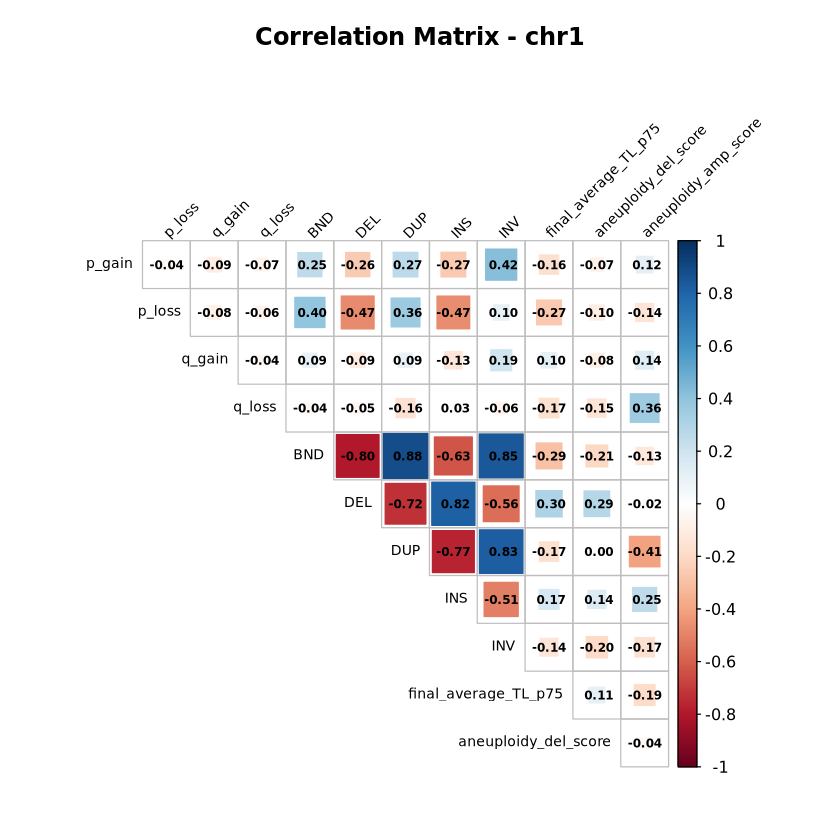

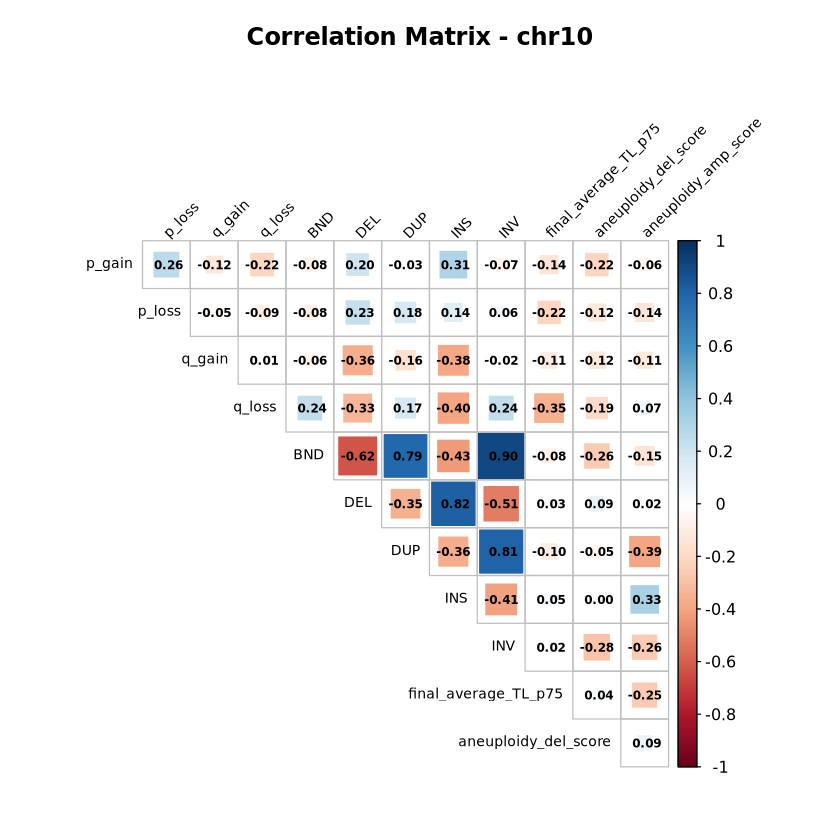

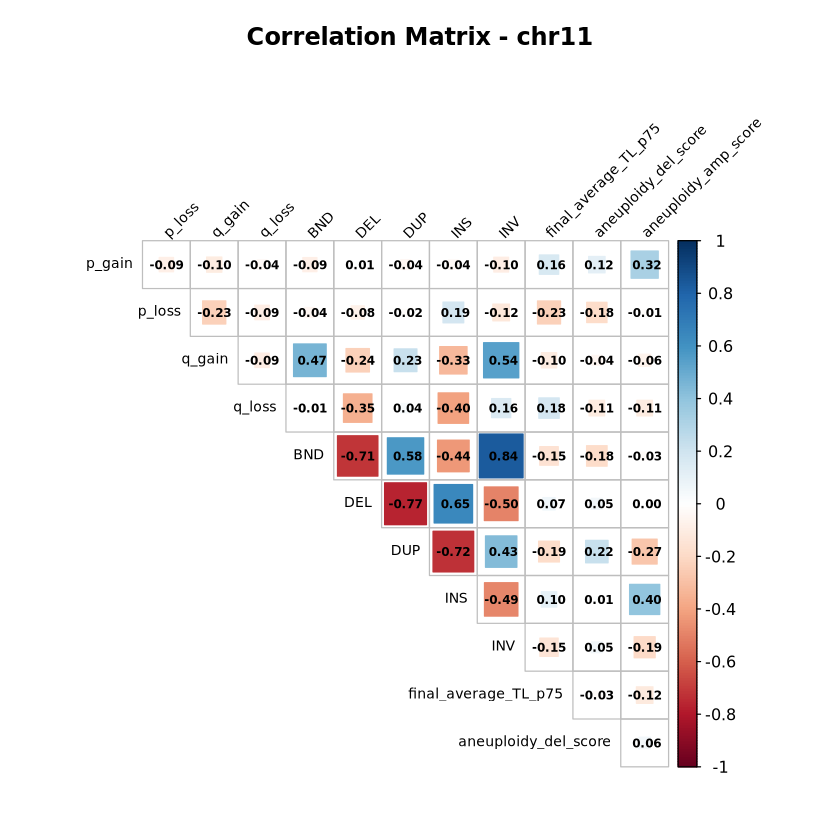

Warning message in cor(df_chrom_numeric, use = "complete.obs"):
“the standard deviation is zero”


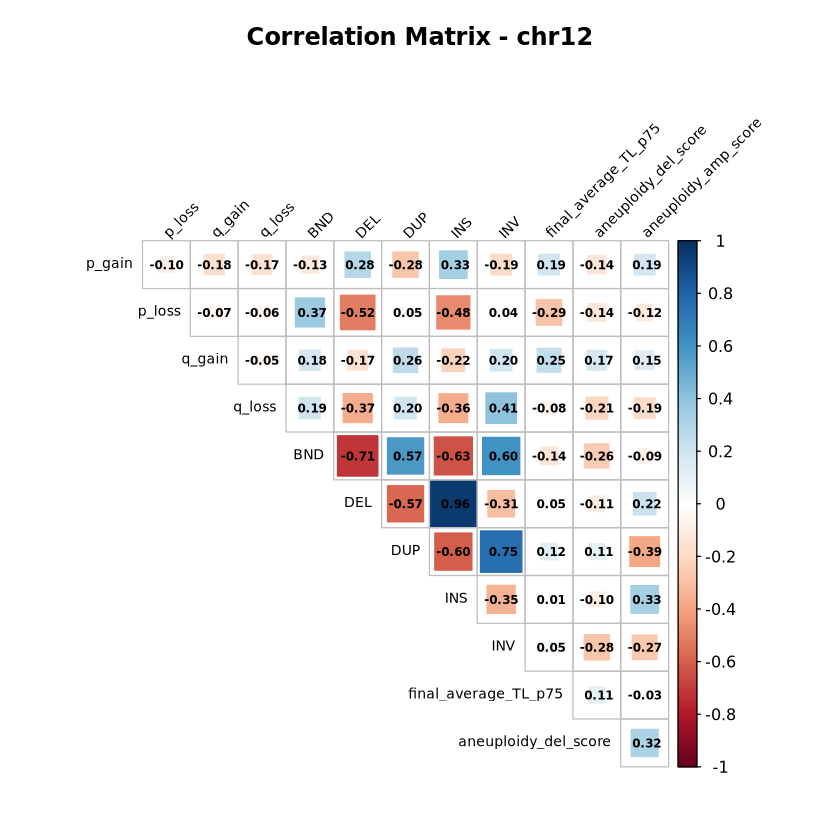

Warning message in cor(df_chrom_numeric, use = "complete.obs"):
“the standard deviation is zero”


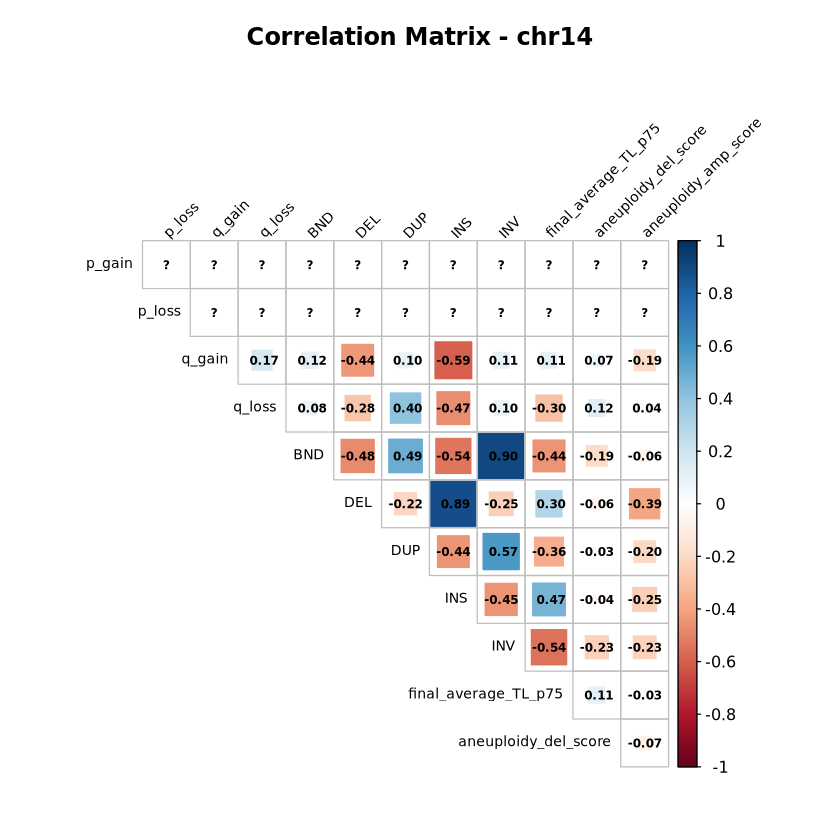

Warning message in cor(df_chrom_numeric, use = "complete.obs"):
“the standard deviation is zero”


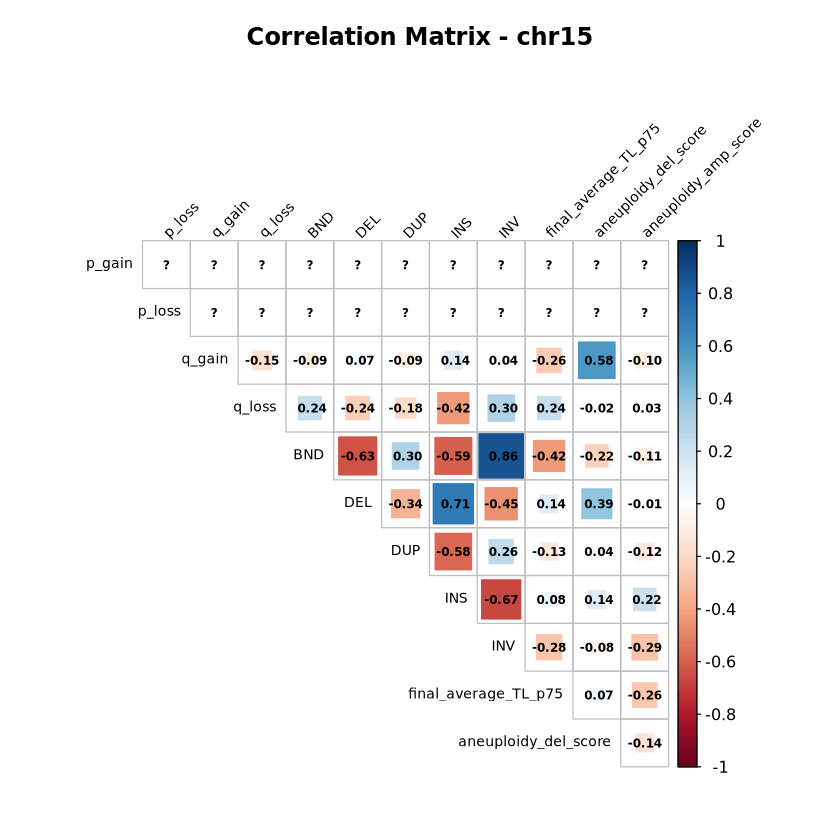

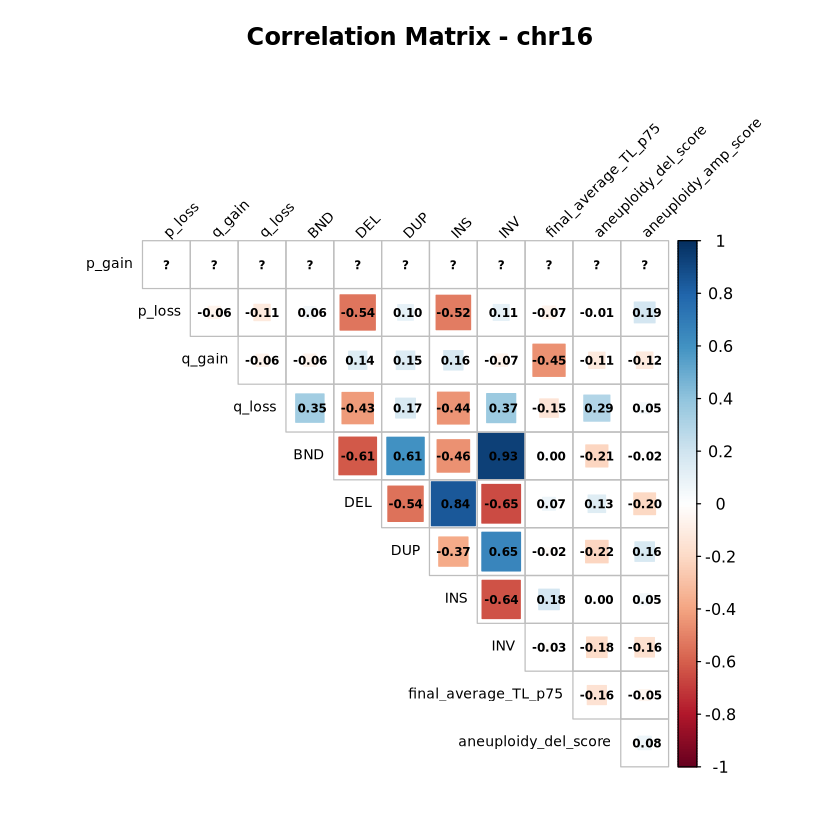

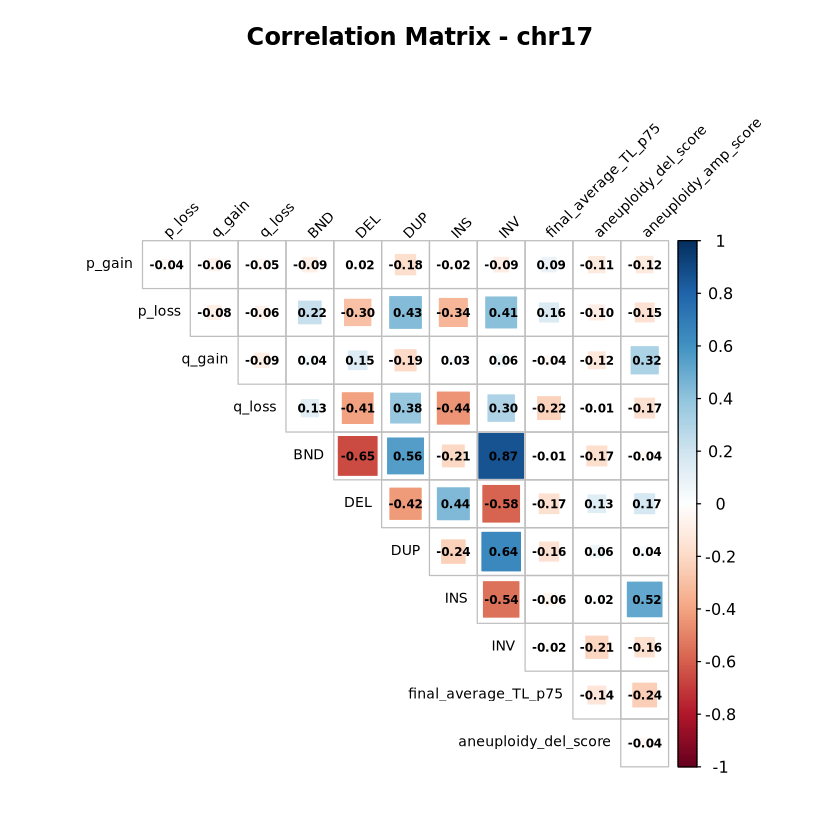

Warning message in cor(df_chrom_numeric, use = "complete.obs"):
“the standard deviation is zero”


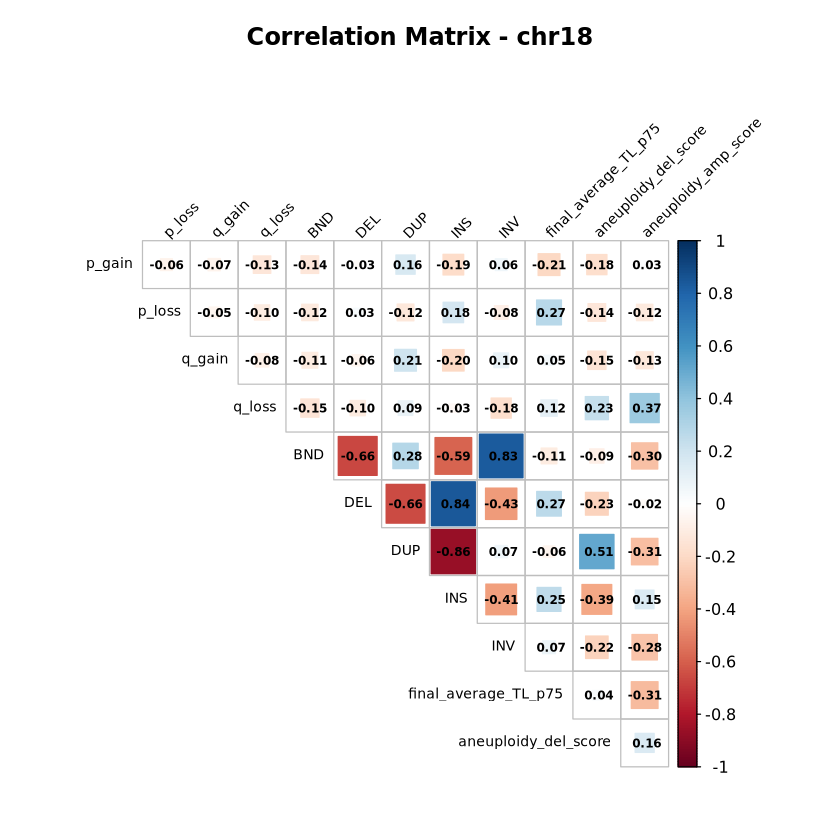

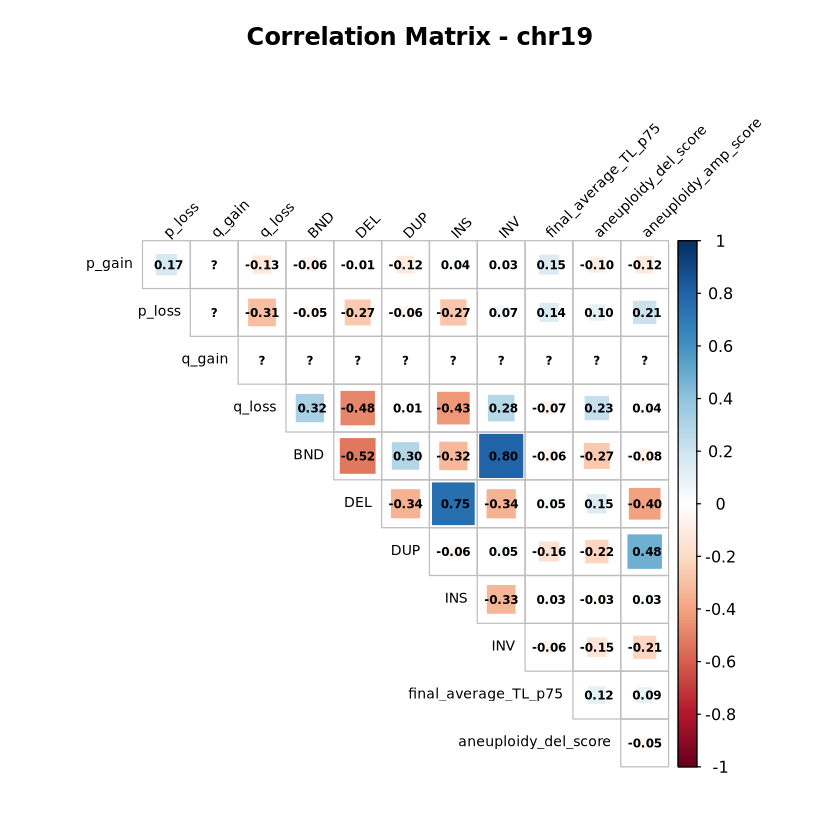

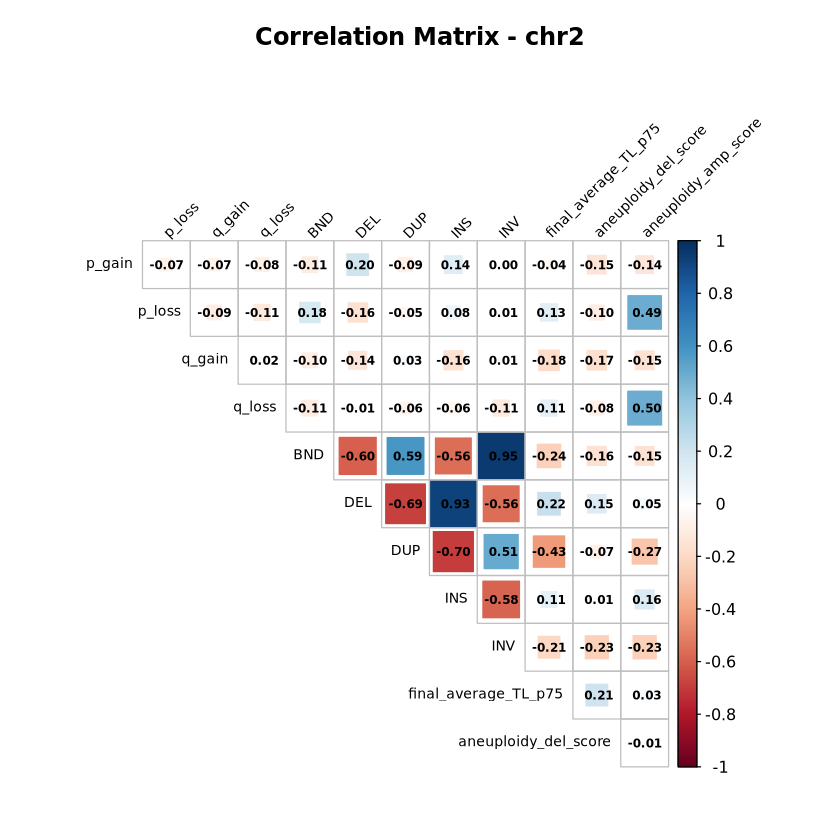

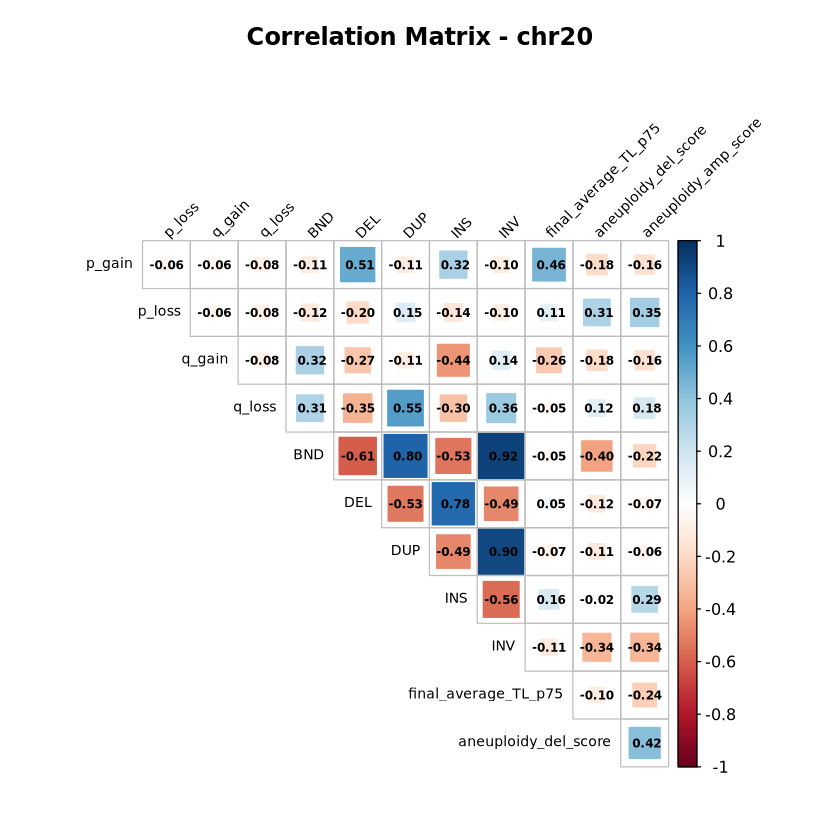

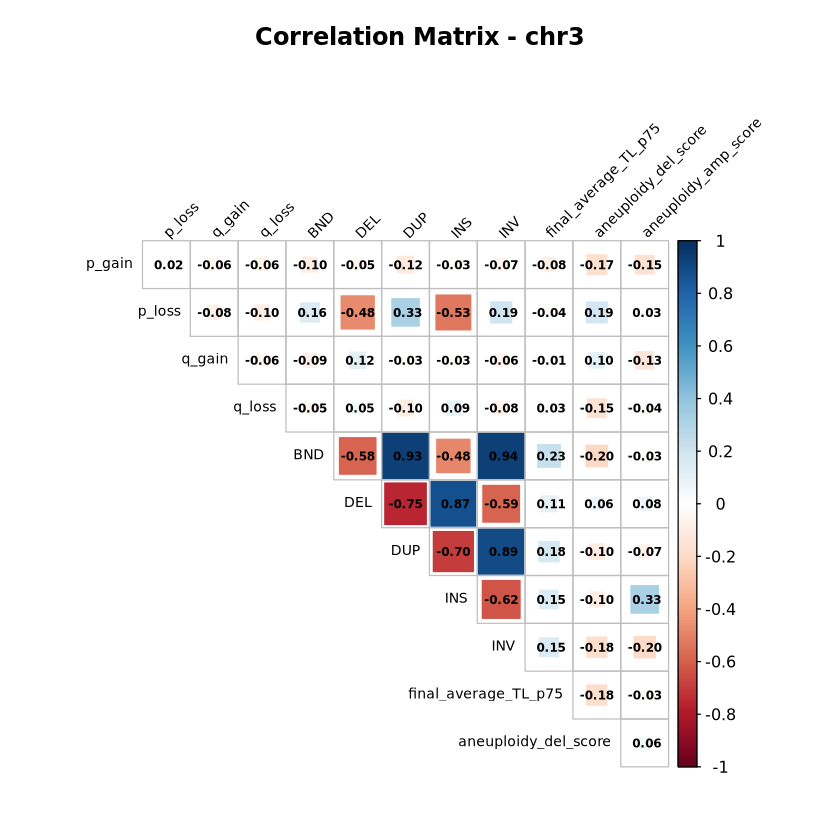

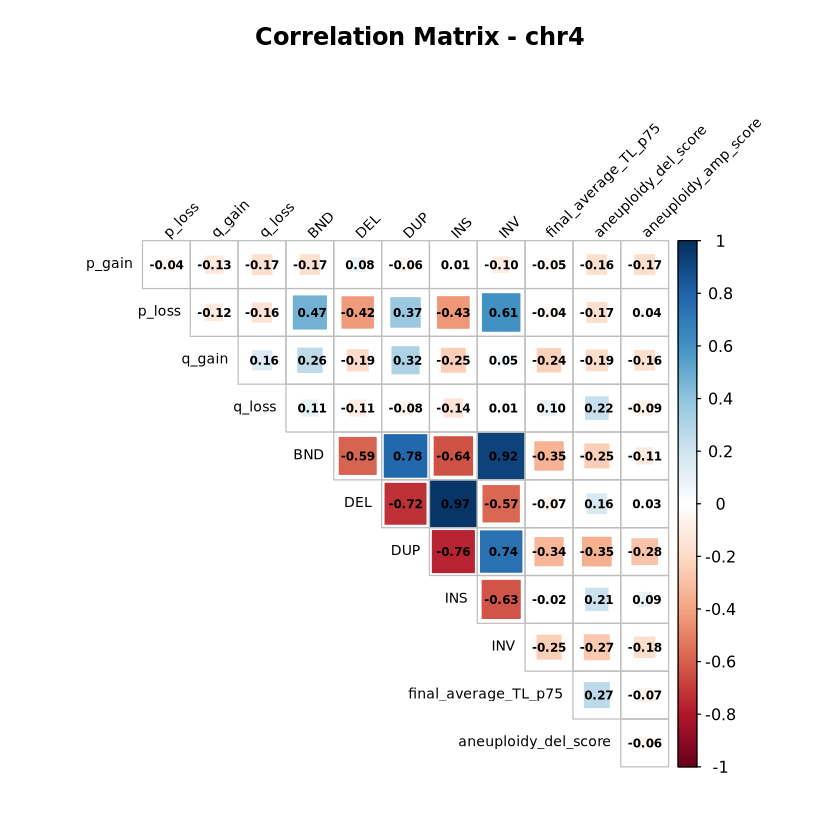

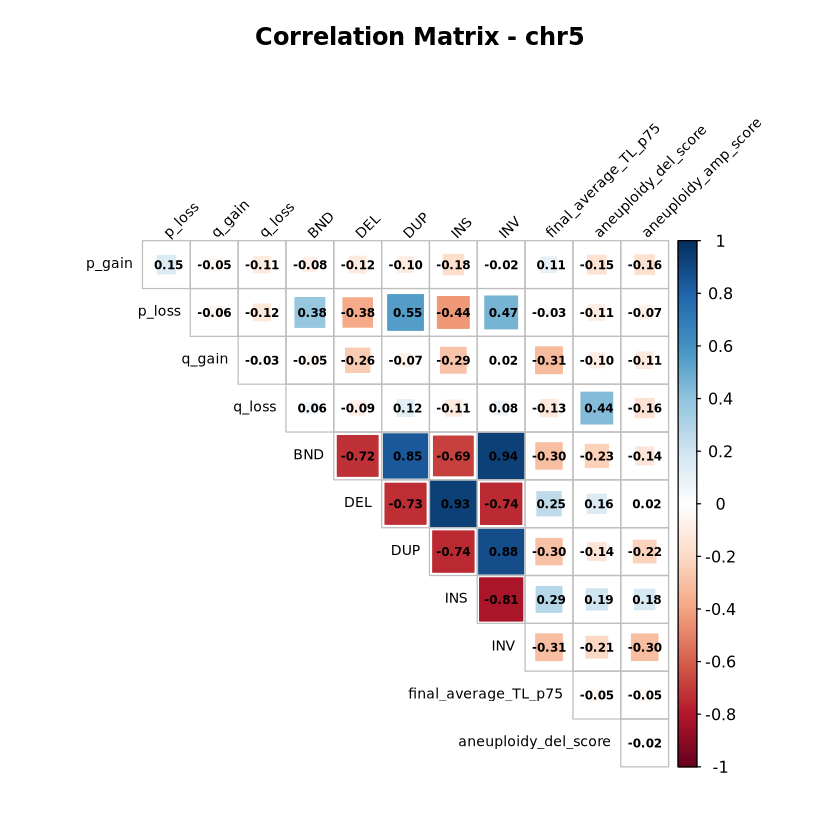

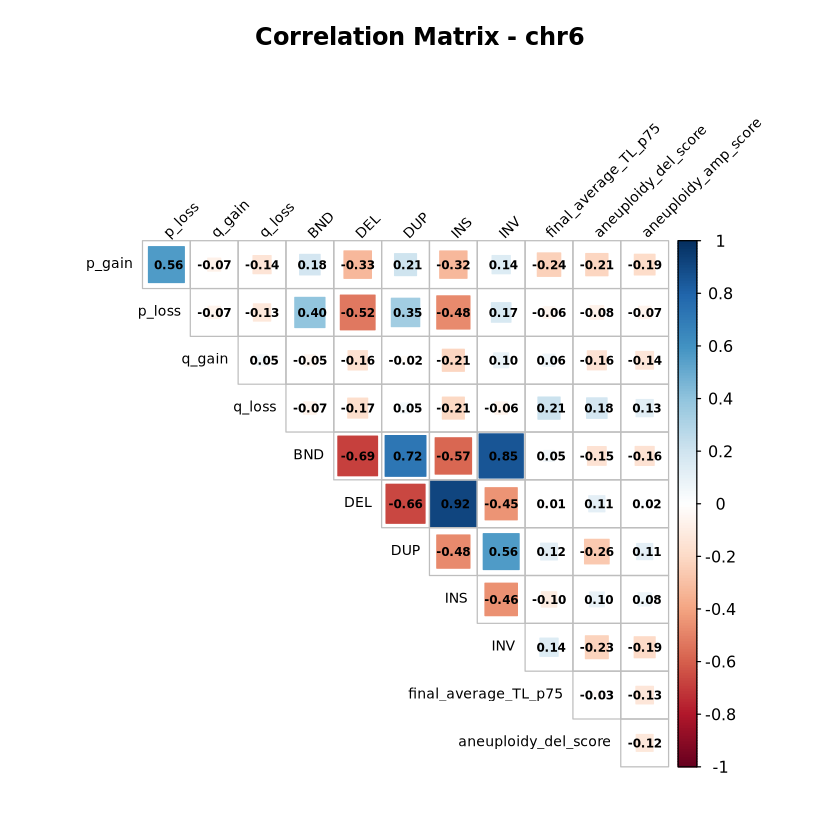

Warning message in cor(df_chrom_numeric, use = "complete.obs"):
“the standard deviation is zero”


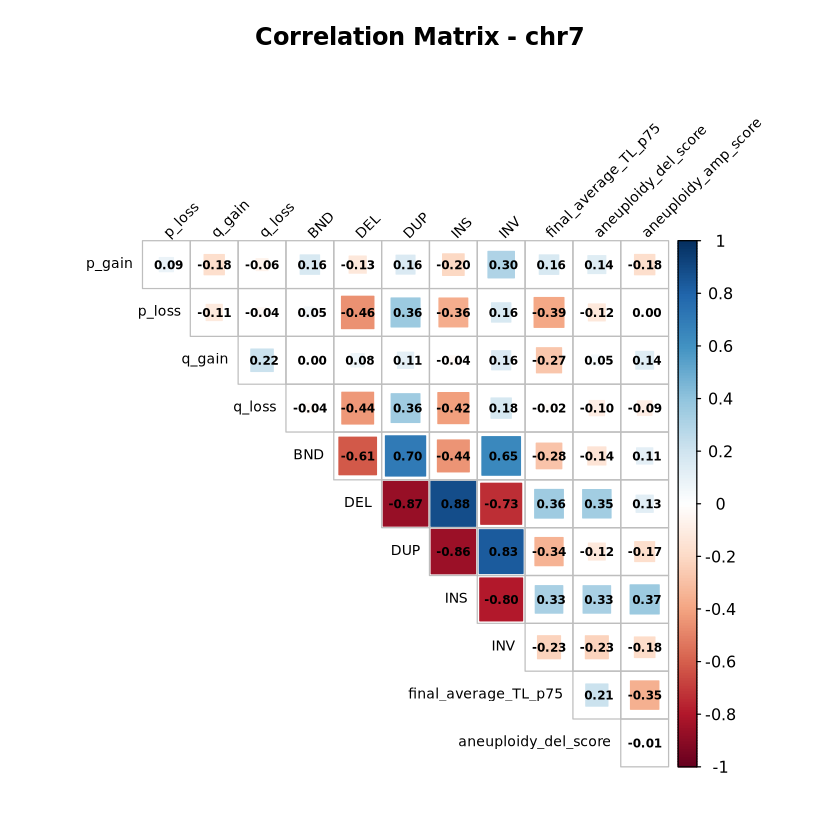

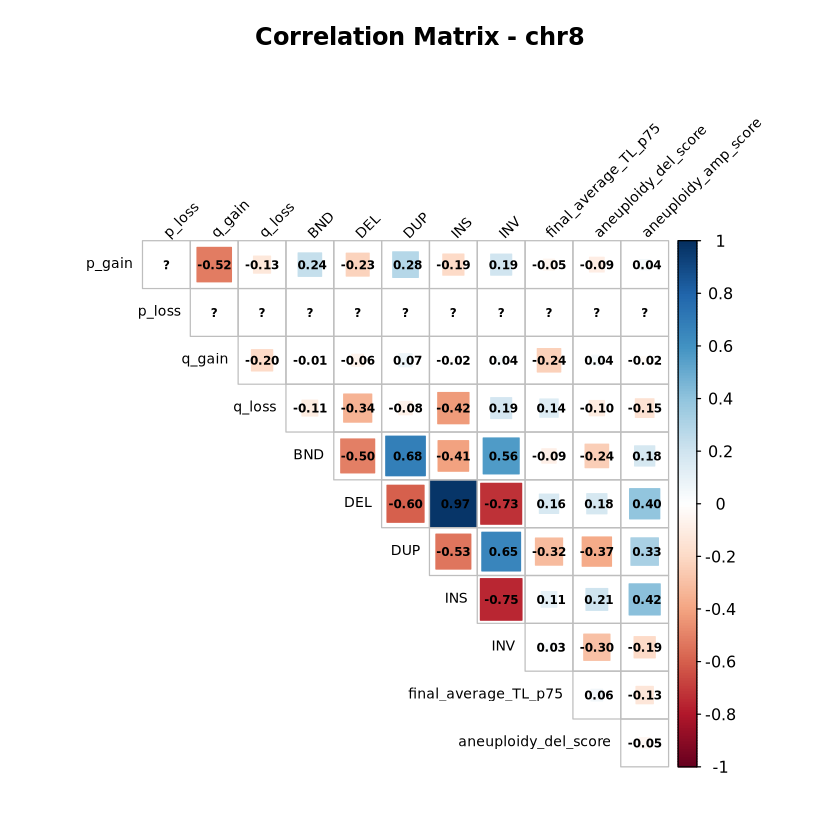

Warning message in cor(df_chrom_numeric, use = "complete.obs"):
“the standard deviation is zero”


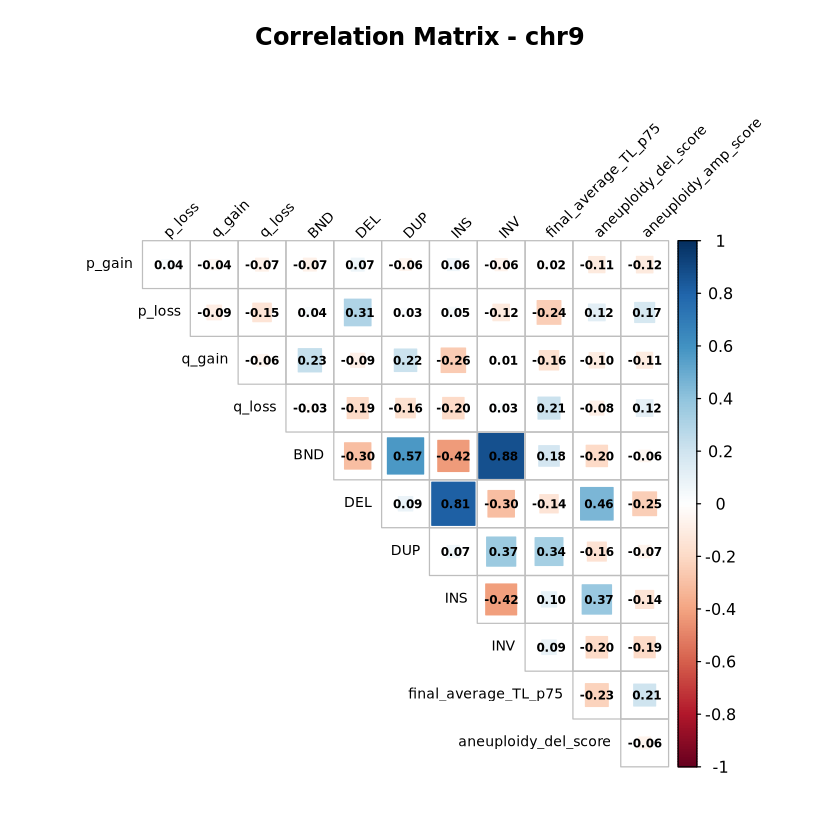

Warning message in cor(df_chrom_numeric, use = "complete.obs"):
“the standard deviation is zero”


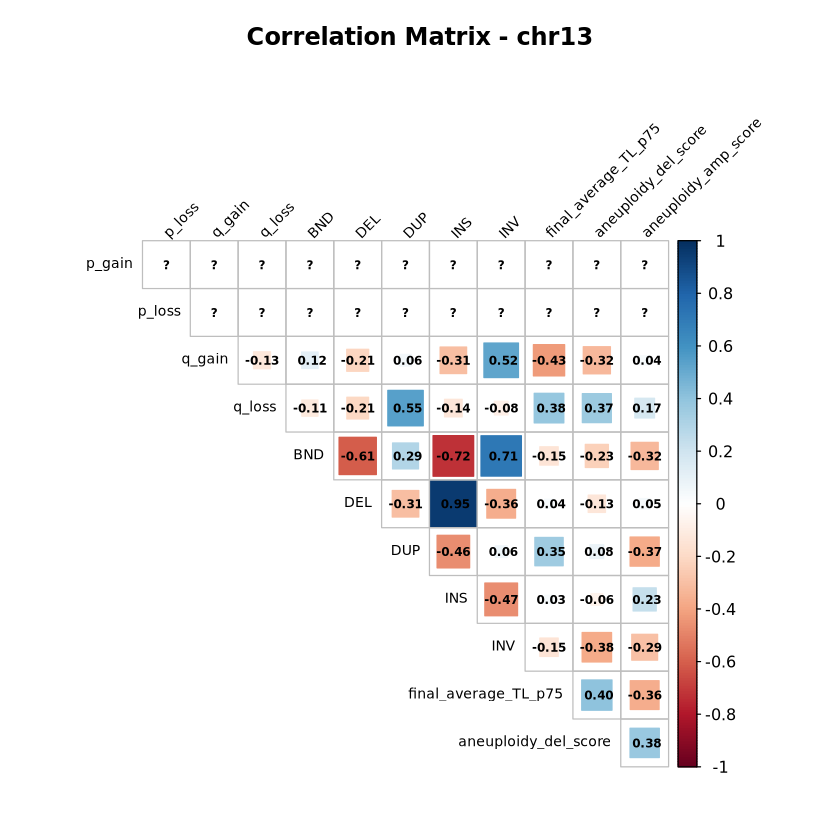

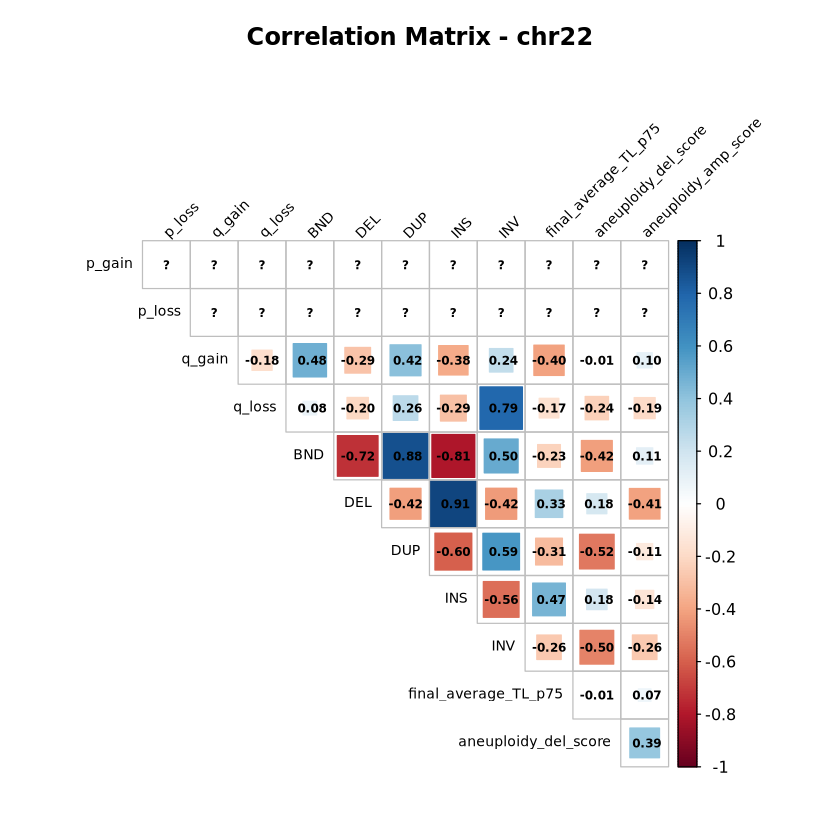

ERROR: [1m[33mError[39m in `gtable_add_grob()`:[22m
[33m![39m `grobs` must be a single grob or a list of grobs, not a list.


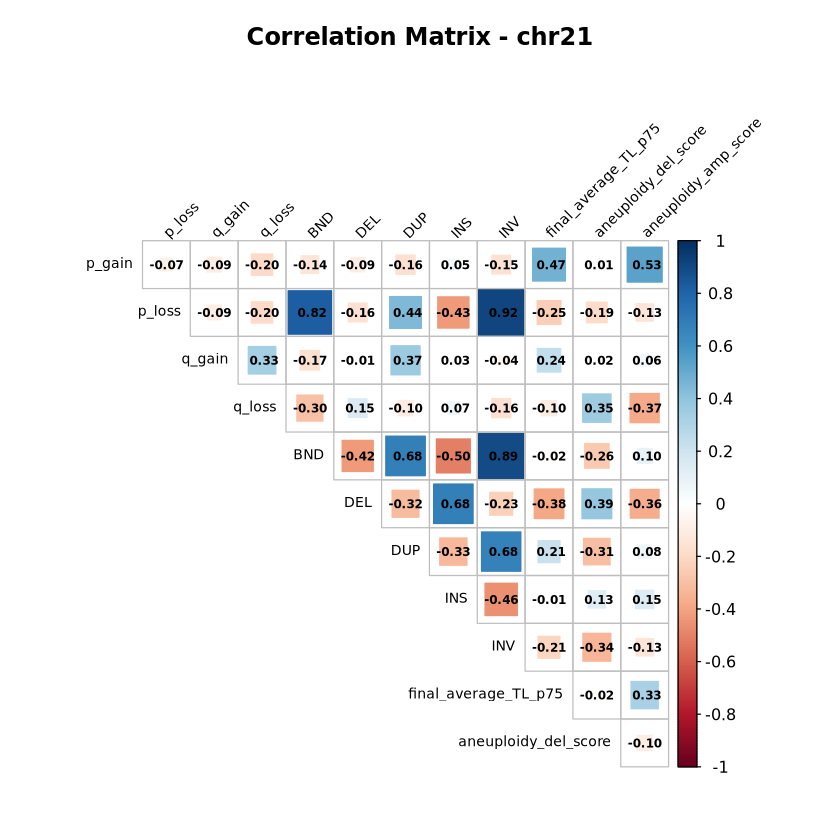

In [9]:

# Assuming your data frame is called df
# 1. Get the list of unique chromosomes
chromosomes <- unique(df$chr)

# 2. Create a list to store individual correlation plots
corplot_list <- list()

# Loop through each chromosome to create individual plots
for (chrom in chromosomes) {
  
  # Filter data for each chromosome
  df_chrom <- filter(df, chr == chrom)
  
  # Select only numeric columns for correlation
  df_chrom_numeric <- df_chrom[, sapply(df_chrom, is.numeric)]
  
  # Calculate the correlation matrix for the chromosome
  cor_matrix <- cor(df_chrom_numeric, use = "complete.obs")
  
  # Create the correlation plot for the current chromosome
  plot <- corrplot(cor_matrix, method = "square", type = "upper", 
                   tl.col = "black", tl.srt = 45, # Labels style
                   addCoef.col = "black", # Add correlation coefficients
                   number.cex = 0.6, # Reduce number size for clarity
                   tl.cex = 0.7, # Adjust label size
                   diag = FALSE, # Hide diagonal
                   mar = c(0, 0, 3, 0), # Adjust margins
                   cl.cex = 0.8, # Adjust color bar text size
                   main = paste("Correlation Matrix -", chrom))  # Title for each plot
  
  # Append the plot to the list
  corplot_list[[chrom]] <- plot
}

# 3. Combine all the individual plots into one
# Using gridExtra to arrange them into a grid
grid.arrange(grobs = corplot_list, ncol = 2)  # Adjust ncol for layout (2 columns here)


In [19]:
library(dplyr)             

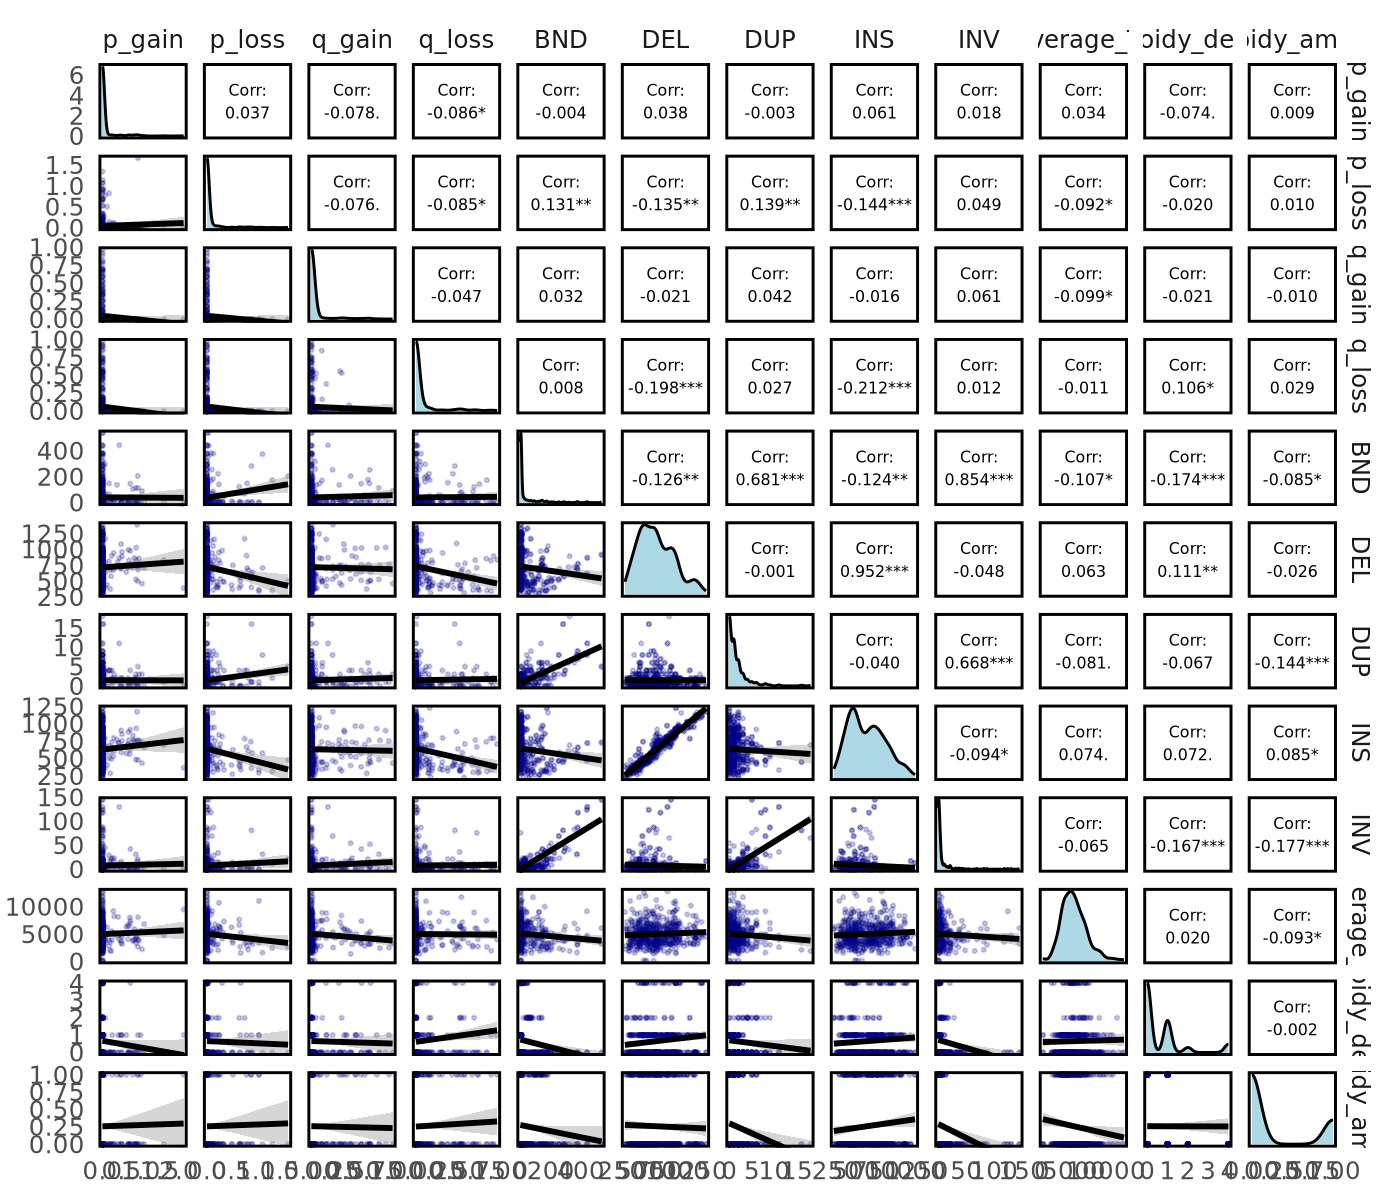

In [49]:

# Select specific chromosomes
#selected_chromosomes <- c("chr9", "chr6", "chr11", "chr19")

# Explicitly use dplyr::filter to avoid conflicts
#df_filtered <- dplyr::filter(df, chr %in% selected_chromosomes)

# Select numeric variables for correlation
selected_vars <- c("p_gain", "p_loss", "q_gain", "q_loss", "BND", 
                   "DEL", "DUP", "INS", "INV", "final_average_TL_p75", "aneuploidy_del_score", "aneuploidy_amp_score")

#df_filtered_selected <- df_filtered %>% dplyr::select(all_of(selected_vars))
df_filtered_selected <- df %>% dplyr::select(all_of(selected_vars))

# Remove columns with zero variance
df_filtered_selected <- df_filtered_selected[, sapply(df_filtered_selected, function(x) sd(x, na.rm = TRUE) > 0)]

# Customize colors for correlation plot
#custom_colors <- c("blue", "white", "red")  # Negative to positive correlation

# Create the correlation plot
p <- ggpairs(df_filtered_selected, 
        upper = list(continuous = wrap("cor", size = 2, color = "black")),  # Smaller text in upper panel
        lower = list(continuous = wrap("smooth", alpha = 0.2, color = "darkblue", size = 0.4)),  # Scatter plots in lower panel
        diag = list(continuous = wrap("densityDiag", fill = "lightblue"))  # Density plots on diagonal
) + 
  theme_minimal() +  
  theme(panel.grid.major = element_blank(),  # Remove background grid lines
        panel.grid.minor = element_blank(),
        panel.border = element_rect(color = "black", fill = NA, size = 1))  # Add border around blocks

options(repr.plot.width = 7, repr.plot.height = 6, repr.plot.res = 200)

# Show the plot
print(p)


Warning message in geom_text(label = label, mapping = mapping, ...):
“Ignoring unknown parameters: `face`”
Warning message in geom_text(label = label, mapping = mapping, ...):
“Ignoring unknown parameters: `face`”
Warning message in geom_text(label = label, mapping = mapping, ...):
“Ignoring unknown parameters: `face`”
Warning message in geom_text(label = label, mapping = mapping, ...):
“Ignoring unknown parameters: `face`”
Warning message in geom_text(label = label, mapping = mapping, ...):
“Ignoring unknown parameters: `face`”
Warning message in geom_text(label = label, mapping = mapping, ...):
“Ignoring unknown parameters: `face`”
Warning message in geom_text(label = label, mapping = mapping, ...):
“Ignoring unknown parameters: `face`”
Warning message in geom_text(label = label, mapping = mapping, ...):
“Ignoring unknown parameters: `face`”
Warning message in geom_text(label = label, mapping = mapping, ...):
“Ignoring unknown parameters: `face`”
Warning message in geom_text(label = 

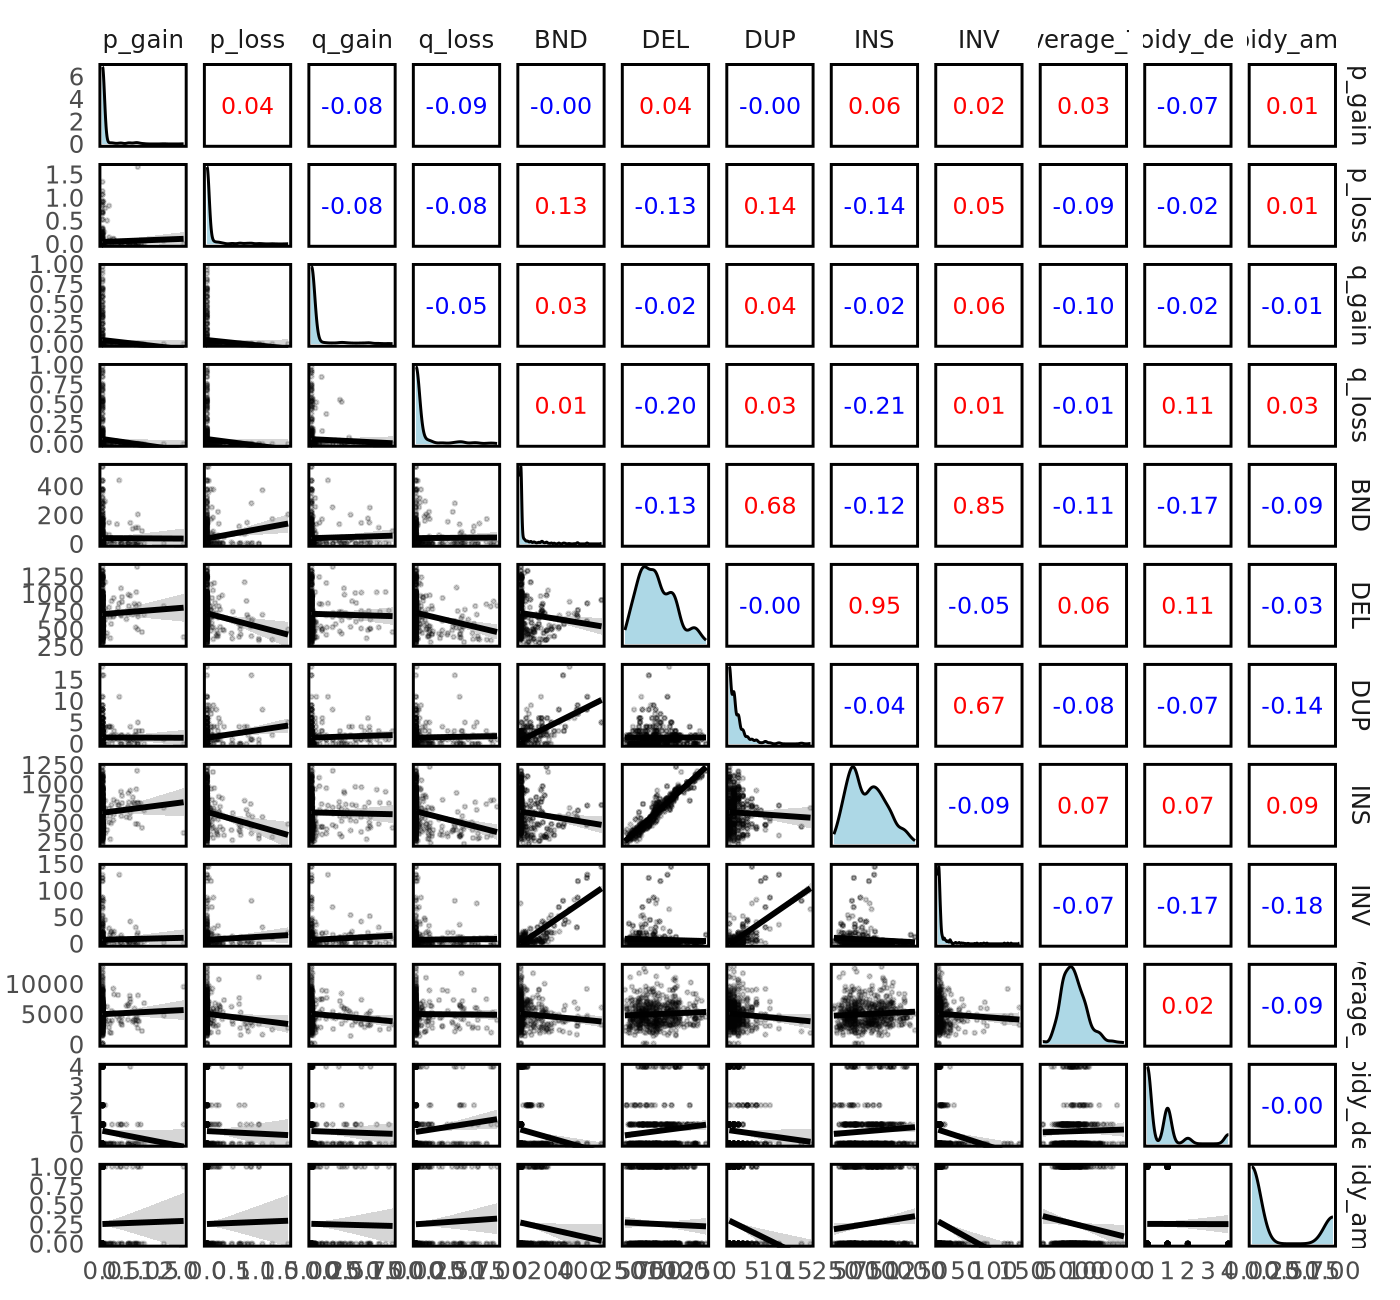

In [50]:
# Custom correlation function with color-coded values
cor_fun <- function(data, mapping, method = "pearson", ...) {
  # Extract variables
  x <- eval_data_col(data, mapping$x)
  y <- eval_data_col(data, mapping$y)
  
  # Compute correlation and p-value
  cor_val <- cor(x, y, method = method, use = "complete.obs")
  p_val <- cor.test(x, y, method = method)$p.value
  
  # Color: red for positive, blue for negative
  col <- ifelse(cor_val > 0, "red", "blue")
  
  # Bold font for significant correlations
  font_face <- ifelse(p_val < 0.05, "bold", "plain")
  
  # Return ggplot with formatted correlation text
  ggally_text(
    label = sprintf("%.2f", cor_val), 
    mapping = aes(), 
    size = 3, color = col, 
    face = font_face
  )
}

# Create the correlation plot
p <- ggpairs(df_filtered_selected, 
        upper = list(continuous = cor_fun, size = 1),  # Custom correlation labels
        lower = list(continuous = wrap("smooth", alpha = 0.2, size = 0.4)),  # Scatter plots in lower panel
        diag = list(continuous = wrap("densityDiag", fill = "lightblue"))  # Density plots on diagonal
) + 
  theme_minimal() +  
  theme(
    panel.grid.major = element_blank(),  # Remove background grid lines
    panel.grid.minor = element_blank(),
    panel.border = element_rect(color = "black", fill = NA, size = 1)  # Add border around blocks
  )
options(repr.plot.width = 7, repr.plot.height = 6.5, repr.plot.res = 200)

# Show the plot
print(p)


Warning message in geom_text(label = label, mapping = mapping, ...):
“Ignoring unknown parameters: `face`”
Warning message in geom_text(label = label, mapping = mapping, ...):
“Ignoring unknown parameters: `face`”
Warning message in geom_text(label = label, mapping = mapping, ...):
“Ignoring unknown parameters: `face`”
Warning message in geom_text(label = label, mapping = mapping, ...):
“Ignoring unknown parameters: `face`”
Warning message in geom_text(label = label, mapping = mapping, ...):
“Ignoring unknown parameters: `face`”
Warning message in geom_text(label = label, mapping = mapping, ...):
“Ignoring unknown parameters: `face`”
Warning message in geom_text(label = label, mapping = mapping, ...):
“Ignoring unknown parameters: `face`”
Warning message in geom_text(label = label, mapping = mapping, ...):
“Ignoring unknown parameters: `face`”
Warning message in geom_text(label = label, mapping = mapping, ...):
“Ignoring unknown parameters: `face`”
Warning message in geom_text(label = 

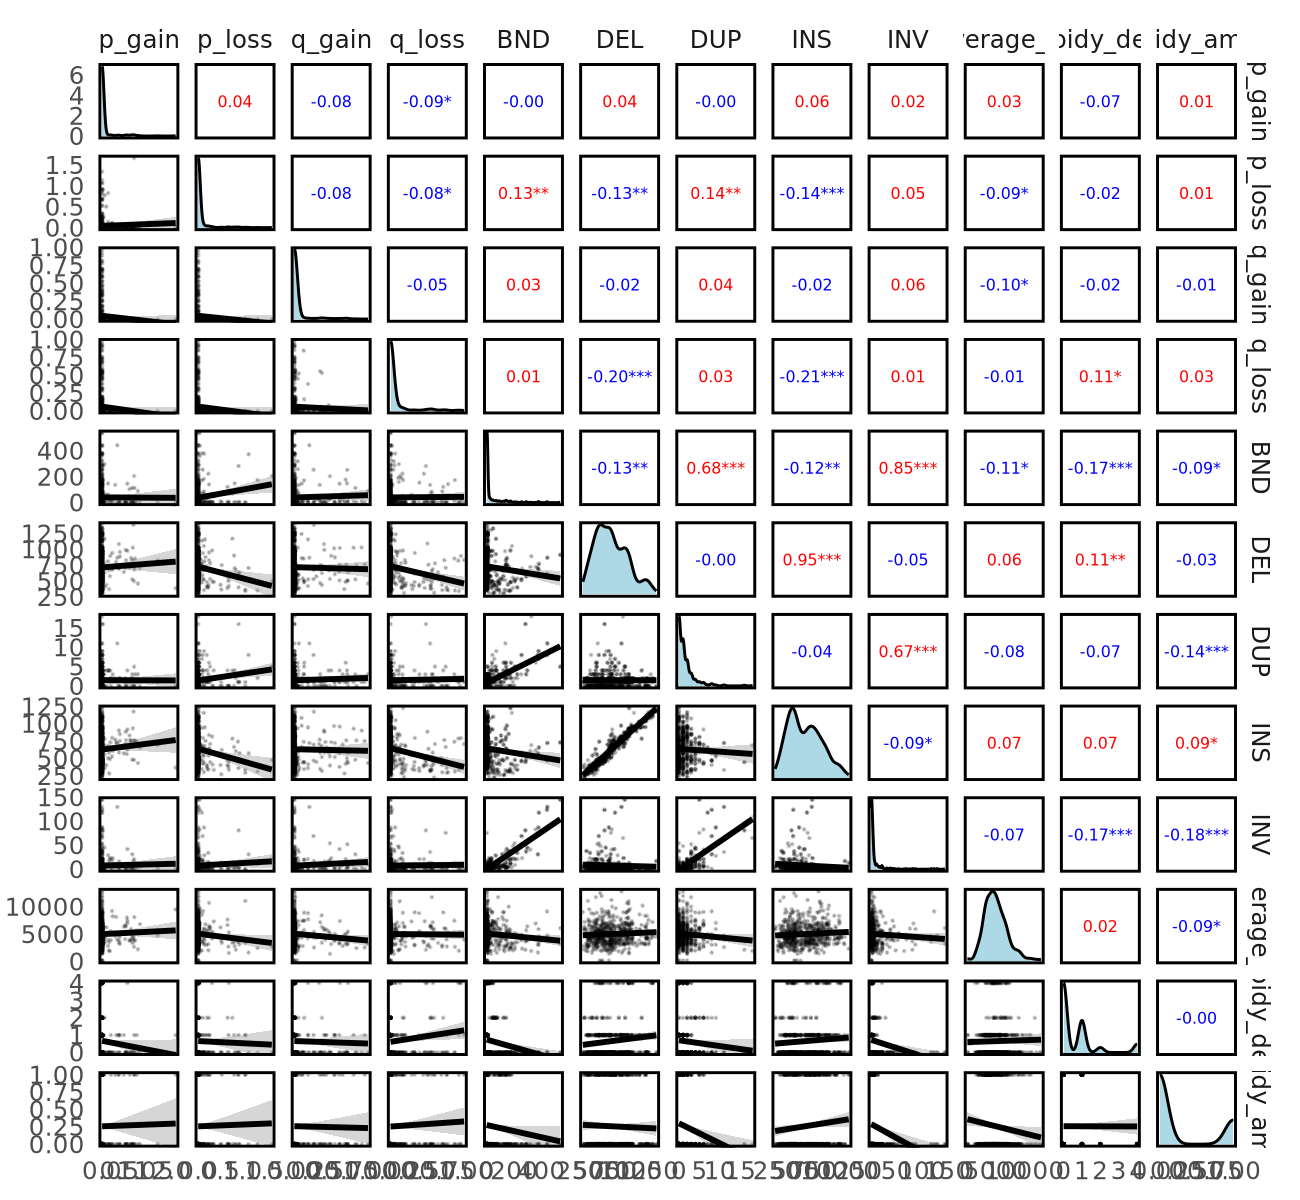

In [59]:
cor_fun <- function(data, mapping, method = "pearson", ...) {
  # Extract variables
  x <- eval_data_col(data, mapping$x)
  y <- eval_data_col(data, mapping$y)
  
  # Compute correlation and p-value
  cor_val <- cor(x, y, method = method, use = "complete.obs")
  p_val <- cor.test(x, y, method = method)$p.value
  
  # Color: red for positive, blue for negative
  col <- ifelse(cor_val > 0, "red", "blue")
  
  # Bold font for significant correlations
  font_face <- ifelse(p_val < 0.05, "bold", "plain")
  
  # Add significance stars based on p-value
  stars <- ifelse(p_val < 0.001, "***",
           ifelse(p_val < 0.01, "**",
           ifelse(p_val < 0.05, "*", "")))
  
  # Format label with correlation value and significance stars
  label <- sprintf("%.2f%s", cor_val, stars)
  
  # Return ggplot with formatted correlation text
  ggally_text(
    label = label, 
    mapping = aes(), 
    size = 2, color = col, 
    face = font_face
  )
}

# Create the correlation plot
p <- ggpairs(df_filtered_selected, 
        upper = list(continuous = cor_fun, size = 1),  # Custom correlation labels
        lower = list(continuous = wrap("smooth", alpha = 0.2, size = 0.1)),  # Scatter plots in lower panel
        diag = list(continuous = wrap("densityDiag", fill = "lightblue"))  # Density plots on diagonal
) + 
  theme_minimal() +  
  theme(
    panel.grid.major = element_blank(),  # Remove background grid lines
    panel.grid.minor = element_blank(),
    panel.border = element_rect(color = "black", fill = NA, size = 1)  # Add border around blocks
  )

# Set plot size
options(repr.plot.width = 6.5, repr.plot.height = 6, repr.plot.res = 200)

# Show the plot
print(p)
